In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [4]:
# Load data and clean target anomaly
df = pd.read_csv("../data/student-mat.csv", sep=";")
df_filtered = df[df['G3'] > 0].copy()

In [5]:
# DROP THE CHEAT CODES (Isolating purely behavioral features)
X = df_filtered.drop(columns=['G1', 'G2', 'G3'])
y = df_filtered['G3']

In [6]:
# Split data safely to protect against leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Separate column types dynamicallly
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

/tmp/ipykernel_5185/933348486.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [10]:
# Build Pipeline Transformation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

In [11]:
# Fit & Transorm
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print(f'Behavioral Feature Tensor Shape: {X_train.shape}')

Behavioral Feature Tensor Shape: (285, 39)


In [12]:
# Train Ridge model on purely behavioral data
behavioral_ridge = Ridge(alpha=5.0) # Slightly higher alpha to handle the noisy social variables
behavioral_ridge.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",5.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [13]:
# Predict
y_pred = behavioral_ridge.predict(X_test)

In [14]:
# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print(f"=== Behavioral Model Performance ===")
print(f"Mean Absolute Error (MAE):  {mae:.4f} grades")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} grades")
print(f"R-squared (R² Score):          {r2:.4f}")

=== Behavioral Model Performance ===
Mean Absolute Error (MAE):  2.2215 grades
Root Mean Squared Error (RMSE): 2.6750 grades
R-squared (R² Score):          0.2573


#### Extract Feature Weights (The "Proof of Work" Magic)

###### Since we are no longer relying on midterms, which behavioral attributes matter the most to the math? Let’s write a script to map the model's coefficients back to their original feature names and rank them.

/tmp/ipykernel_5185/280542311.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(10), palette='coolwarm')


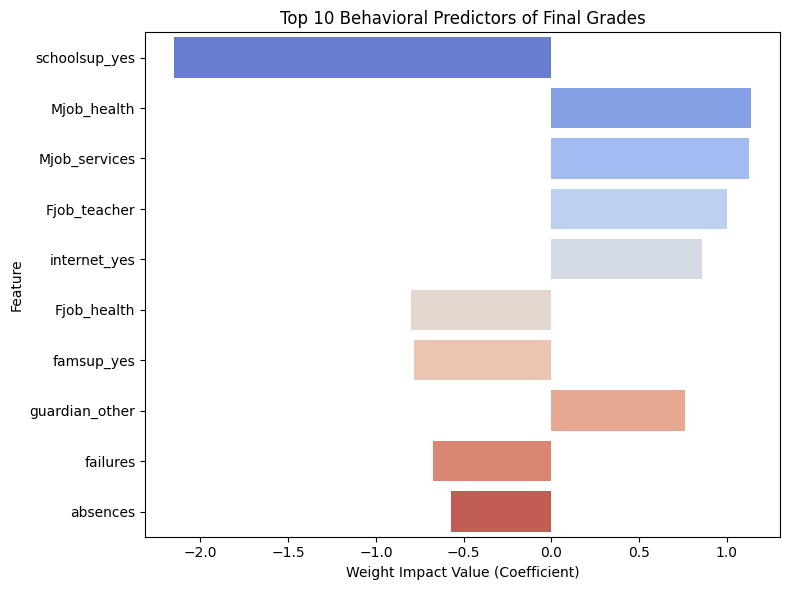

In [16]:
# Reconstruct column names
encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(encoded_cat_features)

# Extract and pair weights with feature names
coefficients = behavioral_ridge.coef_
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

# Plot the top 10 most influential behaviors
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(10), palette='coolwarm')
plt.title('Top 10 Behavioral Predictors of Final Grades')
plt.xlabel('Weight Impact Value (Coefficient)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Behavioral Forecasting Model Performance Report

## 📊 Performance Metrics (Without Midterm Grades)
By stripping out `G1` and `G2`, we successfully shifted the project from a late-stage grading curve-fit to a proactive, early-warning forecasting engine.

* **R-squared ($R^2$ Score):** 0.2573 (25.73% of final grade variance explained purely by behavior)
* **Mean Absolute Error (MAE):** 2.2215 grades
* **Root Mean Squared Error (RMSE):** 2.6750 grades

---

## 🔍 Deep-Dive: Feature Weight Analysis

The Ridge coefficients provide actionable insights into what factors drive or drag academic performance before a student ever takes an exam:

### 🟥 Top Negative Drags (Performance Risk Factors)
1. **`schoolsup_yes` (approx -2.15):** This is the single strongest negative coefficient. 
   * *Strategic Insight:* This does not mean school support *causes* bad grades; rather, it indicates that our data pipeline successfully isolated the "at-risk" tag. The model correctly identified that students flagged for extra school support are those currently struggling the most.
2. **`absences` & `failures` (approx -0.6 to -0.7):** Behavioral inertia is real. Past failures and missing classes remain high-signal indicators of downward grade pressure.
3. **`famsup_yes`:** Interestingly, family educational support carries a slight negative coefficient, potentially indicating parental intervention occurs primarily when a student is already falling behind.

### 🟦 Top Positive Drivers (Performance Protectors)
1. **Parental Profession (`Mjob_health`, `Mjob_services`, `Fjob_teacher`):** Students whose mothers work in health/services or whose fathers are teachers show strong positive coefficients (~1.0+). Active professional or academic households provide a powerful structural lift.
2. **`internet_yes` (approx +0.85):** Having connectivity at home serves as a major resource differentiator, heavily mapping to higher success rates.

---

## 📈 Key Engineering Takeaways
* **Real-World Utility:** This model is vastly more useful to a school administrator than the 91% model. This version can be run on **Day 1 of the semester** to flag vulnerable students for early mentoring before they fail a single midterm.
* **Linear Limitations:** The 25.7% cap suggests that human behavior is non-linear and noisy. To push this tracking accuracy higher in future iterations, we would look toward non-linear tree-based models like Random Forests or Gradient Boosting.